In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from mmtrack import pre_process_mm
from mmtrack import mm_cell_segmentation as mm3seg
from mmtrack import plot_cells
import warnings
import networkx as nx
import tifffile
from skimage.filters import threshold_otsu
import skimage.segmentation as segmentation
from skimage import segmentation, morphology, measure, filters
import scipy.ndimage as ndi
from skimage.filters import threshold_local
import json

Helper functions:

In [2]:
def get_tiff_frame_count(file_path):
	"""Reads a TIFF file and returns the index of the last time frame (T - 1)."""
	try:
		# 1. Read the image data into a NumPy array
		img_stack = tf.imread(file_path)

		# 2. Get the shape of the array
		shape = img_stack.shape

		# 3. Assume the time axis (T) is the first dimension
		if len(shape) >= 3:
			# The last index is T - 1, which is shape[0] - 1
			last_frame_index = shape[0] - 1
			return last_frame_index
		else:
			# Handle case where the file might be a single 2D image (T=1, last index 0)
			return 0

	except FileNotFoundError:
		print(f"Error: TIFF file not found at {file_path}")
		return 0
	except Exception as e:
		print(f"Error reading TIFF file {file_path}: {e}")
		return 0
	
def overlap(bbox1, bbox2):
    """Checks if two bounding boxes overlap."""
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])
    return x1 < x2 and y1 < y2

Fill in file you want to troubleshoot and the experiment dictionary in json text format

In [3]:
file_name = "/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing"

In [4]:
exp_dict ='{"baeS": {"022": ["377"]}}'
base_dir = file_name

In [ ]:
EXP_DICT='{"baeS": {"022": ["377", "679", "980", "1206", "1281"]}}'


In [ ]:
STRAIN_DICT='{"baeS": {"baeS": ["022"]}}'

These are the values that will need to be troubleshooted

In [5]:
# the following are the default values for parameters excluding file names and Json
base_dir= base_dir
exp_dict_json= exp_dict
start_frame=0
end_frame=None  # Passes None if not provided
phase_c_str='0'
otsu_thresh=1.5
first_open=4
dist_thresh=3.0
second_open_size=3
min_area=100
max_area=1000
small_merge_thresh=100

seg_FOV_dict = json.loads(exp_dict)


The following is code to test on the entire timelapse and gauge where to start troubleshooting

Error reading TIFF file /Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/baeS/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_022_region_377_c_0.tif: name 'tf' is not defined


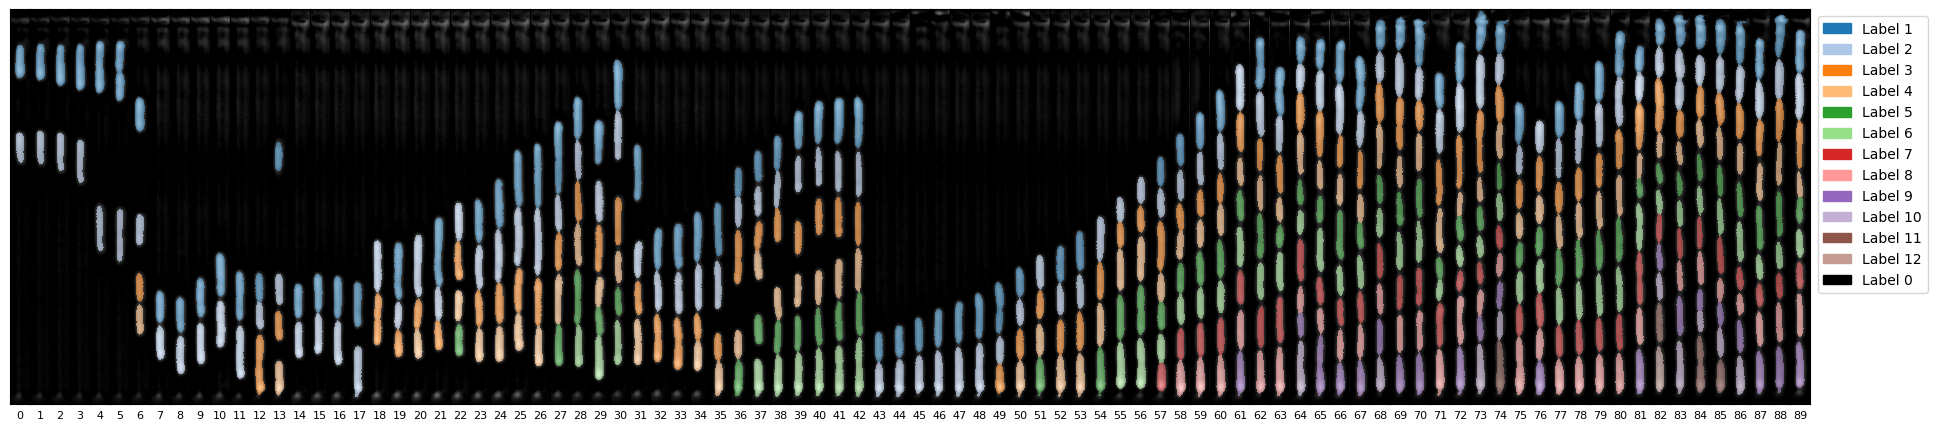

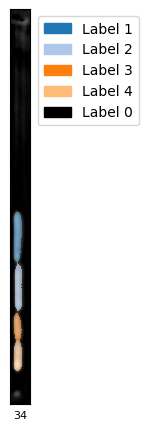

In [12]:
#previous troubhleshooting setup
phase_channel = '0'
fluor_channel = '1'
for folder, fov_dict in seg_FOV_dict.items():
    for fov_id in fov_dict.keys():
        ana_peak_ids = fov_dict[fov_id]
        for peak_id in ana_peak_ids:
            current_end_frame = end_frame
            path_to_phase_stack = f'/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            if current_end_frame is None:
                current_end_frame = get_tiff_frame_count(path_to_phase_stack)
            path_to_fluor_stack = f'/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/subtracted_FOV_{fov_id}_region_{peak_id}_c_{fluor_channel}.tif'
            output_path = f'/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/outputs'
            labeled_stack = f'/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/{folder}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted/mm3_segmented_subtracted_FOV_{fov_id}_region_{peak_id}_c_{phase_channel}.tif'
            mm3seg.segment_chnl_stack(
                   path_to_phase_stack,
                   output_path,
                   OTSU_threshold=1.4,
                   first_opening=2,
                   distance_threshold=2,
                   second_opening_size=1,
                   min_cell_area=50,
				   max_cell_area=700,
                   small_merge_area_threshold=50)
            plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=0, end=90, alpha=0.5)
            plot_cells.display_segmentation(path_to_phase_stack, mask_path = labeled_stack, start=34, end=35, alpha=0.5)

# Troubleshooting begins here:
First pick a timeframe

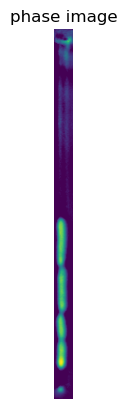

In [8]:
image = tifffile.imread(path_to_phase_stack)[34]
plt.figure()
plt.imshow(image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

# Otsu threshold
Test different otsu_thresh values. The mask will be dependent on the otsu threshold, individual cell labeling will depend on everything else so it is okay if cells are somewhat joined together

Main goal is to make sure we see the correct number of cells

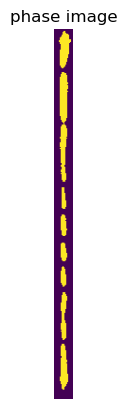

In [10]:
# this is the value you can mess with 
otsu_thresh = 1.5
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        thresh = filters.threshold_otsu(image)
    thresholded = image > otsu_thresh * thresh
    
except Exception as e:
        print(f"Error in initial processing: {e}")

plt.figure()
plt.imshow(thresholded)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()


# troubleshooting 
the following is an attempt to use local otsu to fix segmentation

In [ ]:
import skimage as ski
radius = 100
footprint = ski.morphology.disk(radius)
local_otsu = ski.filters.rank.otsu(image, footprint)
threshold_local = image >= local_otsu

block_size = 501
local_thresh = ski.filters.threshold_local(image, block_size, offset=10)
binary_local = image > local_thresh

# First opening
Here wee mess with the first opening. Ultimately want to maintain centroids here so don't worry about how small cells are. 

You may need to change the morphological opening shape for either diagnol or spherical 

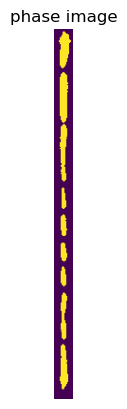

In [12]:
# change but is int not double 
first_opening = 1
#if spherical opening use the following code 
morph = morphology.binary_opening(thresholded, morphology.disk(first_opening))

#if diagnol opening use the following code
# diagonal_footprint = np.zeros((first_opening, first_opening))
# np.fill_diagonal(diagonal_footprint, 1)
# morph = morphology.binary_opening(thresholded, diagonal_footprint)

plt.figure()
plt.imshow(morph)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

# Distance threshold 
Again goal is to retain the number of objects here and make sure cells are separate 

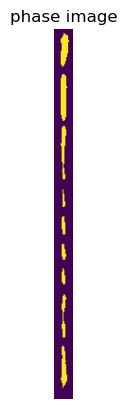

In [13]:
distance_threshold = 2
distance = ndi.distance_transform_edt(morph)
distance_thresh = distance >= distance_threshold
plt.figure()
plt.imshow(distance_thresh)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()



# Second opening 
Further segment cells, can opt to not use it by setting the value to 0

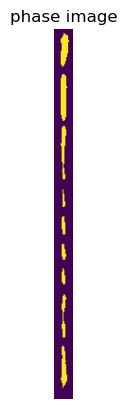

In [15]:
second_opening_size = 0
distance_opened = morphology.binary_opening(distance_thresh, morphology.disk(second_opening_size))
plt.figure()
plt.imshow(distance_opened)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

# labeling and markers 
Apply labels to cells that have been segmented. Labeled will be used for watershed I believe markers will be used only to create a mask 

In [16]:
labeled, num_labels = morphology.label(distance_opened, connectivity=1, return_num=True)
markers = morphology.label(labeled, connectivity=1)
markers = markers.astype(np.int32)

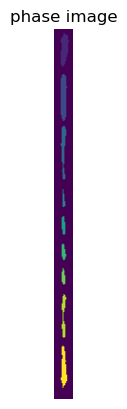

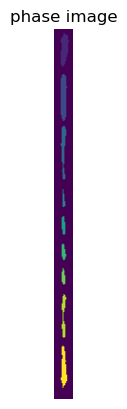

In [17]:
plt.figure()
plt.imshow(labeled)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

plt.figure()
plt.imshow(markers)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()


# Watershed begins here 

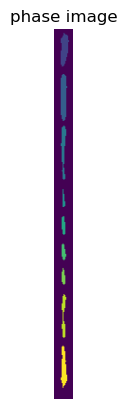

In [18]:
thresholded_watershed = distance_opened
image_float = image.astype(np.float64)
markers[thresholded_watershed == 0] = -1

plt.figure()
plt.imshow(markers)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/skimage/segmentation/random_walker_segmentation.py:545: UserWarning: Random walker only segments unlabeled areas, where labels == 0. No zero valued areas in labels were found. Returning provided labels.
  (labels, nlabels, mask, inds_isolated_seeds, isolated_values) = _preprocess(labels)


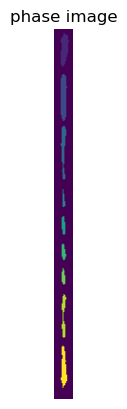

In [19]:
labeled_image = segmentation.random_walker(-1 * image_float, markers)
labeled_image[labeled_image == -1] = 0
plt.figure()
plt.imshow(labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

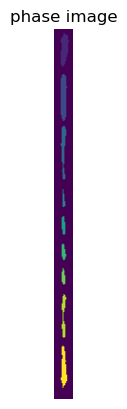

In [20]:
small_merge_area_threshold=50
regions = measure.regionprops(labeled_image)
if regions:
        bboxes = np.array([region.bbox for region in regions])
        areas = np.array([region.area for region in regions])
        graph = nx.Graph()

        for i, bbox1 in enumerate(bboxes):
            for j, bbox2 in enumerate(bboxes):
                if i != j and overlap(bbox1, bbox2) and areas[i] < small_merge_area_threshold and areas[j] < small_merge_area_threshold:
                    graph.add_edge(regions[i].label, regions[j].label)

        for component in nx.connected_components(graph):
            if len(component) > 1:
                merged_mask = np.isin(labeled_image, list(component))
                new_label = np.max(labeled_image) + 1
                labeled_image[merged_mask] = new_label
                for label in component:
                    labeled_image[labeled_image == label] = 0

        labeled_image, _ = morphology.label(labeled_image, connectivity=1, return_num=True)

plt.figure()
plt.imshow(labeled_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()
